# Salesforce Funnel Analysis - Financial Sector (2025)

This notebook demonstrates how to load and analyze Salesforce Leads and Opportunities data, focusing on the financial and insurance sector, using simulated data and macroeconomic indicators from **2025**.

In [1]:
import sys
import os
from pathlib import Path


current_dir = Path(os.getcwd())
project_root = None


for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
else:
    print("Warning: Project root not found. 'src' import may fail.")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

## Loading Data (Processed)

In [2]:
df_leads = pd.read_csv(project_root / 'data/processed/sf_leads_processed.csv')
if 'CreatedDate' in df_leads.columns:
    df_leads['CreatedDate'] = pd.to_datetime(df_leads['CreatedDate'])
print(f"Leads loaded: {len(df_leads)}")
df_leads.head()

Leads loaded: 1500


,Status,LeadSource,CreatedDate,AnnualRevenue,Sector,ProductInterest,State,IsConverted
0,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0
1,Closed - Not Converted,Trade Show,2025-02-05,22731976,Financial Services,Corporate Life Insurance,Rio de Janeiro,0
2,New,LinkedIn,2025-04-07,580326,Insurance,Fleet Auto Insurance,Bahia,0
3,Working,Web,2025-11-04,7781616,Financial Services,Pension Fund Management,Minas Gerais,0
4,Working,LinkedIn,2025-08-20,75651702,Financial Services,Fleet Auto Insurance,Sao Paulo,0


In [3]:
df_opps = pd.read_csv(project_root / 'data/processed/sf_opportunities_processed.csv')
if 'CreatedDate' in df_opps.columns:
    df_opps['CreatedDate'] = pd.to_datetime(df_opps['CreatedDate'])
if 'CloseDate' in df_opps.columns:
    df_opps['CloseDate'] = pd.to_datetime(df_opps['CloseDate'])
print(f"Opportunities loaded: {len(df_opps)}")
df_opps.head()

Opportunities loaded: 515


,StageName,Amount,CreatedDate,CloseDate,Probability,LeadSource,Product
0,Closed Won,51441,2025-10-15,2025-12-07,100,Trade Show,Pension Fund Management
1,Closed Lost,13265,2025-08-27,2025-10-01,0,Web,Corporate Life Insurance
2,Closed Lost,310784,2025-06-08,2025-08-22,0,LinkedIn,Directors & Officers (D&O)
3,Closed Lost,25426,2025-11-19,2026-04-17,0,Trade Show,Corporate Life Insurance
4,Negotiation/Review,32806,2025-05-13,2025-07-29,90,Trade Show,Corporate Life Insurance


In [4]:
df_macro = pd.read_csv(project_root / 'data/processed/macro_indicators_processed.csv')
if 'Date' in df_macro.columns:
    df_macro['Date'] = pd.to_datetime(df_macro['Date'])
print(f"Macro data loaded: {len(df_macro)}")
df_macro.head()

Macro data loaded: 11


,Date,Selic,IPCA,Dollar
0,2025-01-01,0.045833,0.16,6.021173
1,2025-02-01,0.049037,1.31,5.765045
2,2025-03-01,0.050508,0.56,5.746216
3,2025-04-01,0.052531,0.43,5.783085
4,2025-05-01,0.053936,0.26,5.666781


## Leads Analysis

/var/folders/lr/jkxd531x1653y7cj8y049_lc0000gn/T/ipykernel_13657/41129135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_leads, x='Status', palette='viridis', order=df_leads['Status'].value_counts().index)


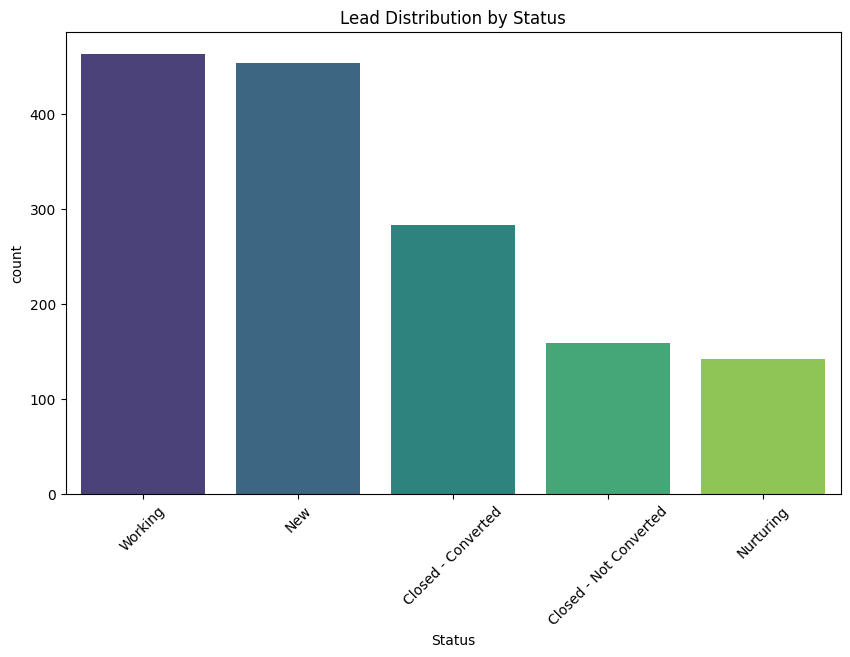

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_leads, x='Status', palette='viridis', order=df_leads['Status'].value_counts().index)
plt.title('Lead Distribution by Status')
plt.xticks(rotation=45)
plt.show()

/var/folders/lr/jkxd531x1653y7cj8y049_lc0000gn/T/ipykernel_13657/729373762.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_leads, y='Sector', palette='magma', order=df_leads['Sector'].value_counts().index)


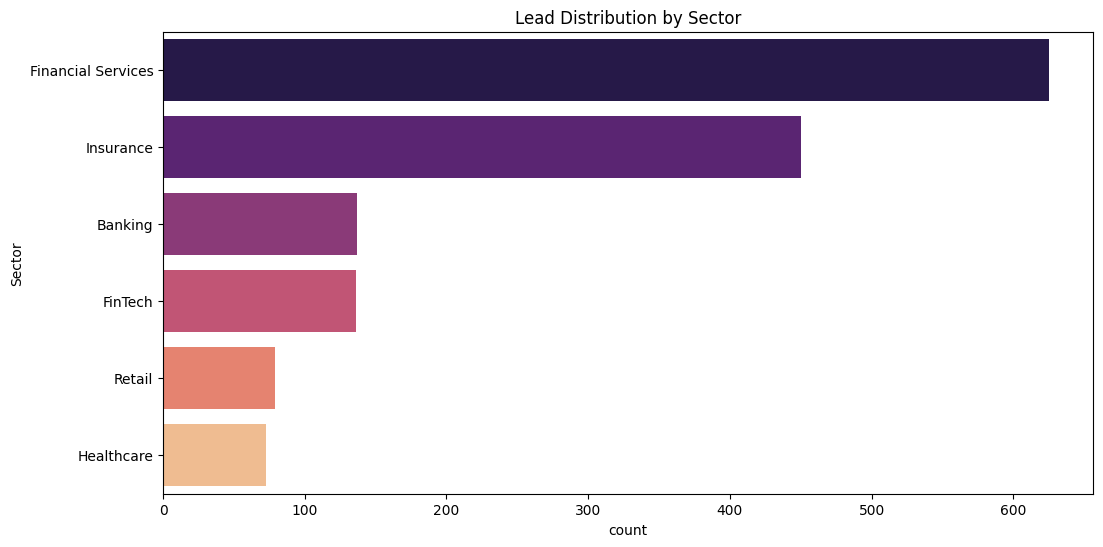

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_leads, y='Sector', palette='magma', order=df_leads['Sector'].value_counts().index)
plt.title('Lead Distribution by Sector')
plt.show()

/var/folders/lr/jkxd531x1653y7cj8y049_lc0000gn/T/ipykernel_13657/788384706.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_leads, y='ProductInterest', palette='coolwarm', order=df_leads['ProductInterest'].value_counts().index)


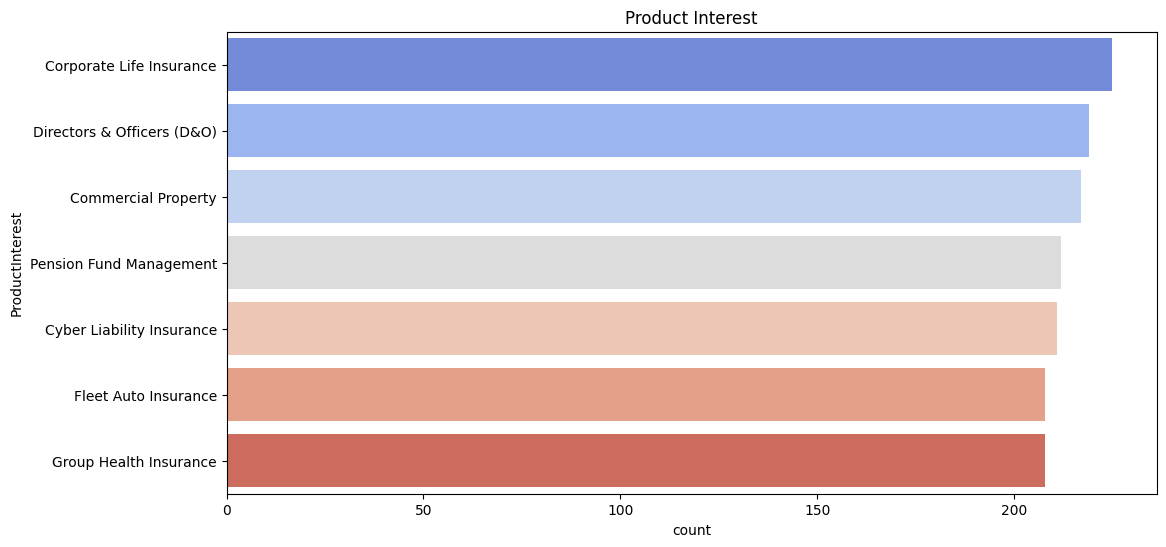

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_leads, y='ProductInterest', palette='coolwarm', order=df_leads['ProductInterest'].value_counts().index)
plt.title('Product Interest')
plt.show()

## Opportunities Analysis

/var/folders/lr/jkxd531x1653y7cj8y049_lc0000gn/T/ipykernel_13657/1060771796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stage_amount, x='Amount', y='StageName', palette='Blues_d')


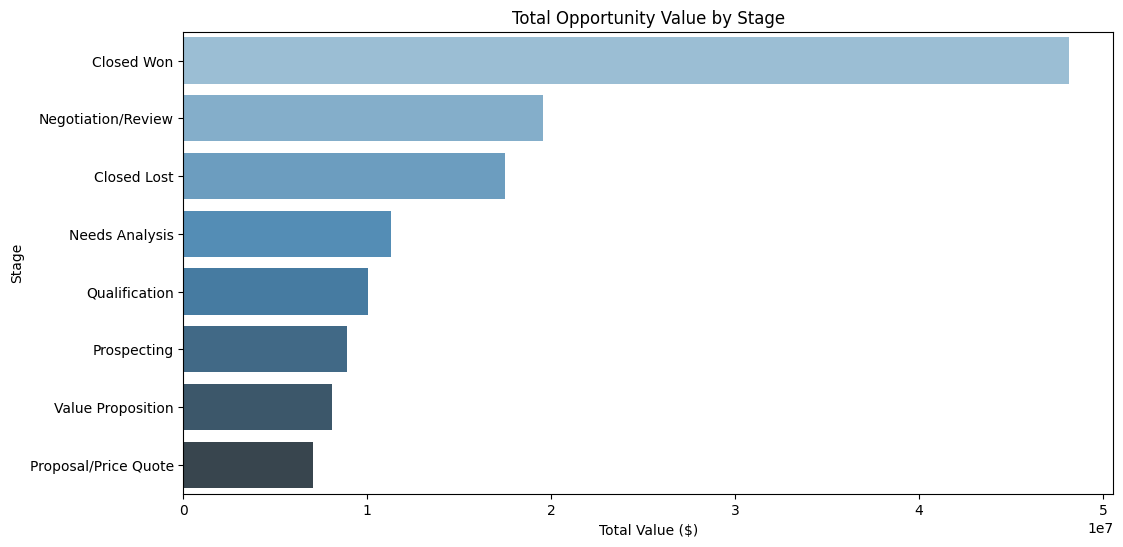

In [8]:
stage_amount = df_opps.groupby('StageName')['Amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=stage_amount, x='Amount', y='StageName', palette='Blues_d')
plt.title('Total Opportunity Value by Stage')
plt.xlabel('Total Value ($)')
plt.ylabel('Stage')
plt.show()

/var/folders/lr/jkxd531x1653y7cj8y049_lc0000gn/T/ipykernel_13657/3260778017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_amount, x='Amount', y='Product', palette='Greens_d')


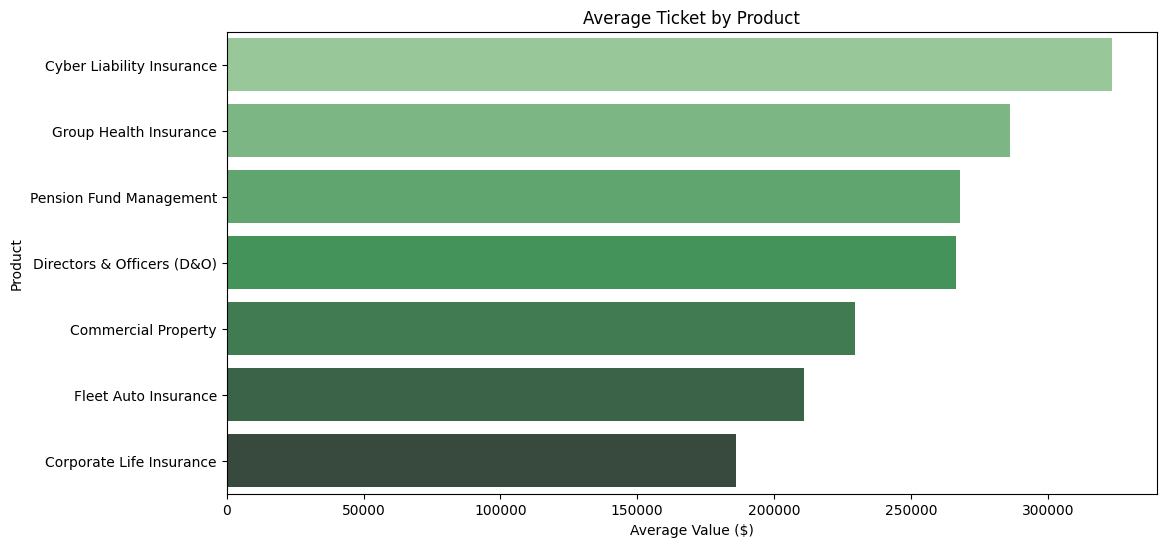

In [9]:
product_amount = df_opps.groupby('Product')['Amount'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=product_amount, x='Amount', y='Product', palette='Greens_d')
plt.title('Average Ticket by Product')
plt.xlabel('Average Value ($)')
plt.show()

## Macroeconomic Analysis (2025)

Let's cross-reference Lead data with economic indicators to understand the scenario impact.

In [10]:


df_leads['Month'] = df_leads['CreatedDate'].dt.to_period('M').dt.to_timestamp()


df_enriched = pd.merge(
    df_leads,
    df_macro,
    left_on='Month',
    right_on='Date',
    how='left'
)
df_enriched.head()

,Status,LeadSource,CreatedDate,AnnualRevenue,Sector,ProductInterest,State,IsConverted,Month,Date,Selic,IPCA,Dollar
0,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,2025-10-01,2025-10-01,0.055131,0.09,5.384926
1,Closed - Not Converted,Trade Show,2025-02-05,22731976,Financial Services,Corporate Life Insurance,Rio de Janeiro,0,2025-02-01,2025-02-01,0.049037,1.31,5.765045
2,New,LinkedIn,2025-04-07,580326,Insurance,Fleet Auto Insurance,Bahia,0,2025-04-01,2025-04-01,0.052531,0.43,5.783085
3,Working,Web,2025-11-04,7781616,Financial Services,Pension Fund Management,Minas Gerais,0,2025-11-01,2025-11-01,0.055131,NaN,5.340253
4,Working,LinkedIn,2025-08-20,75651702,Financial Services,Fleet Auto Insurance,Sao Paulo,0,2025-08-01,2025-08-01,0.055131,-0.11,5.446324


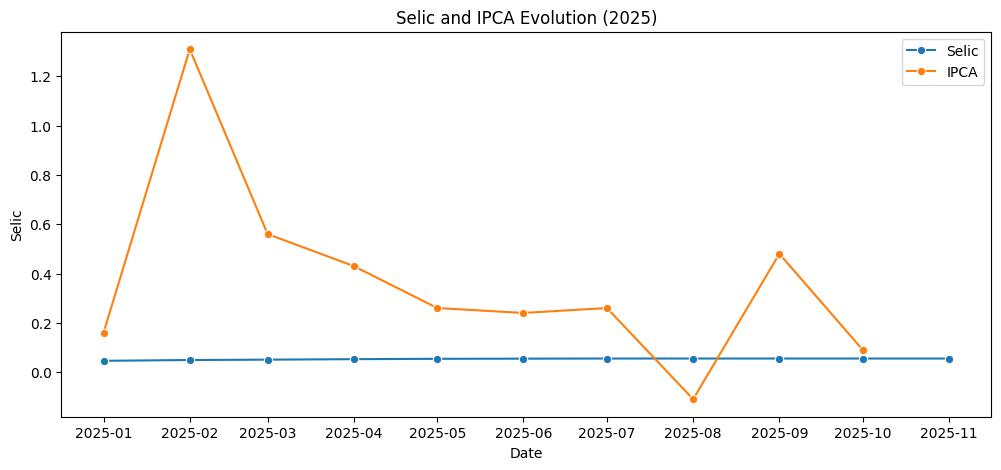

In [11]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_macro, x='Date', y='Selic', label='Selic', marker='o')
sns.lineplot(data=df_macro, x='Date', y='IPCA', label='IPCA', marker='o')
plt.title('Selic and IPCA Evolution (2025)')
plt.show()

/var/folders/lr/jkxd531x1653y7cj8y049_lc0000gn/T/ipykernel_13657/1569512357.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=selic_product, x='Selic', y='ProductInterest', palette='Reds_d')


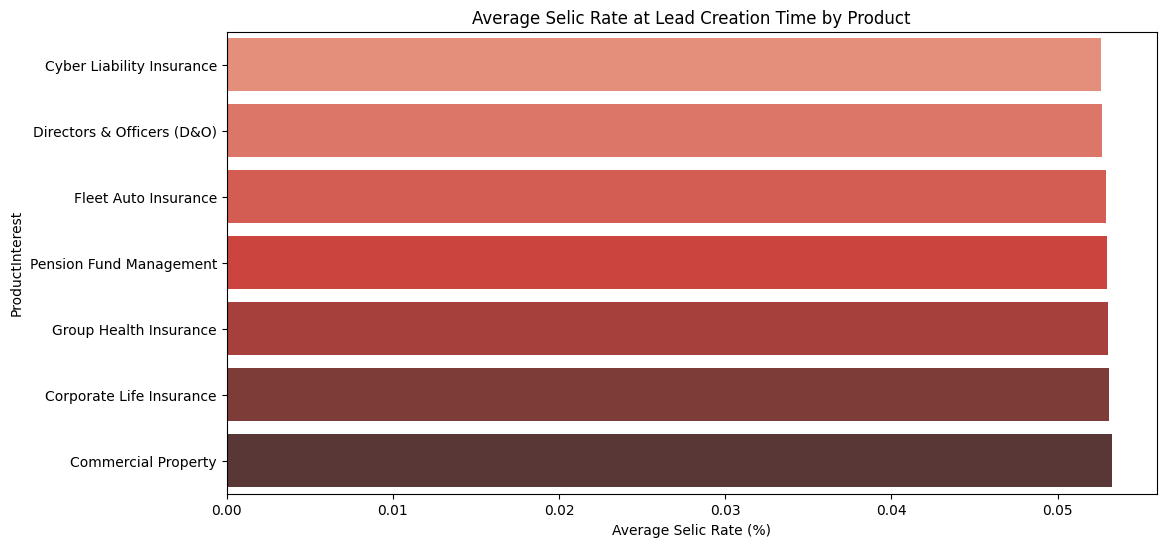

In [12]:
selic_product = df_enriched.groupby('ProductInterest')['Selic'].mean().sort_values().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=selic_product, x='Selic', y='ProductInterest', palette='Reds_d')
plt.title('Average Selic Rate at Lead Creation Time by Product')
plt.xlabel('Average Selic Rate (%)')
plt.show()